# 📘 PySpark

В этом уроке мы разберём практическое применение PySpark для аналитики пользовательской активности.
На реальном наборе данных научимся:

* запускать Spark и читать данные;
* выполнять первичный анализ данных в Spark DataFrame;
* применять фильтры, группировки и агрегаты;
* вычислять метрики активности клиентов;
* конвертировать Spark-данные в pandas (и обратно);
* корректно объединять данные и **избегать утечки данных** при создании признаков;
* формировать фичи на основе активности клиентов только из прошлых событий (до snapshot);
* решать задачи на фильтрацию, агрегацию и категоризацию клиентов в Spark.


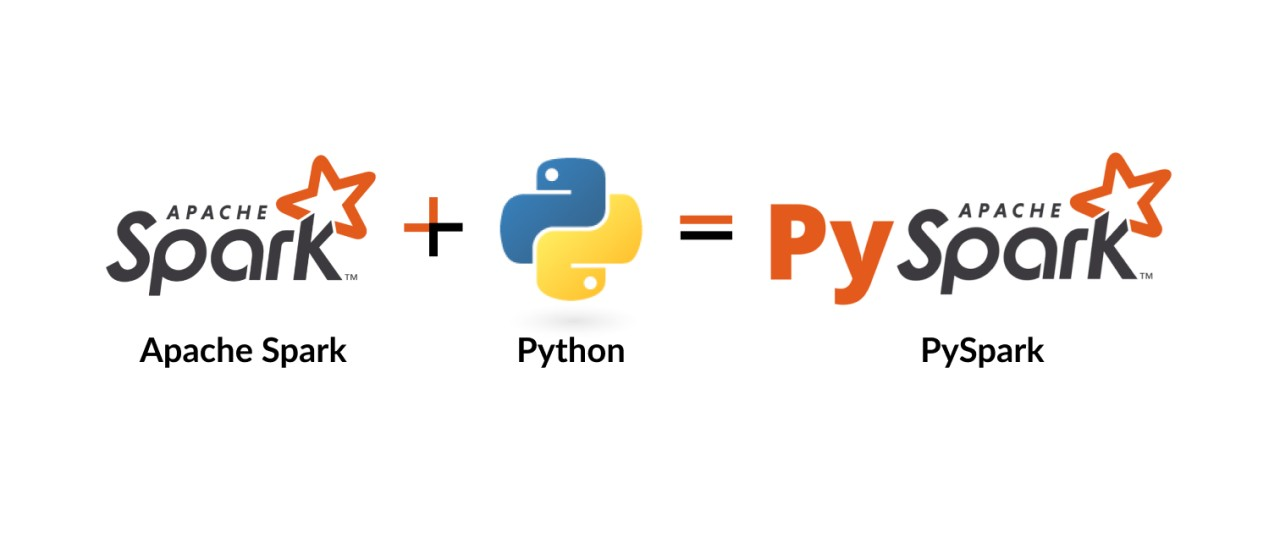

## 📥 Загружаем данные

In [9]:
# Установка PySpark
# !apt-get update
# !apt-get install -y openjdk-11-jdk
# !pip install pyspark

In [10]:
import requests
import os

url = "https://raw.githubusercontent.com/totiela/stepik_simulator_ds/main/lessons/lesson_3_4/3_4_activity.csv"
local_path = "tmp/3_4_activity.csv"

if not os.path.exists(local_path):
    r = requests.get(url)
    r.raise_for_status()
    with open(local_path, "wb") as f:
        f.write(r.content)
    print("Файл скачан:", local_path)

## ✨ Создание Spark-сессии

In [11]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
        .appName("LessonPySpark")
        .getOrCreate()
)

spark

PySparkRuntimeError: [JAVA_GATEWAY_EXITED] Java gateway process exited before sending its port number.

In [ ]:
# чтение спарк-датафрейма

activity_df = (
    spark.read
    .option("header", "true")
    .option("inferSchema", "true")
    .csv(local_path)
)

## 🔎 Первичная разведка

In [ ]:
type(activity_df)

In [ ]:
# Посмотрим схему
activity_df.printSchema()

In [ ]:
# Посмотрим первые строки
activity_df.show(5, truncate=False)

In [ ]:
# Сколько всего строк и клиентов?
print("Всего записей:", activity_df.count())
print("Уникальных клиентов:", activity_df.select("client_id").distinct().count())

##🧹 Фильтрация данных

In [ ]:
from pyspark.sql import functions as F

# активности только типа APP_LOGIN
app_logins_df = activity_df.filter(activity_df.activity_type == "APP_LOGIN")
app_logins_df.show(5)

In [ ]:
# Сколько таких логов?
app_login_count = app_logins_df.count()
print("Количество APP_LOGIN событий:", app_login_count)

In [ ]:
%%time

# клиенты, у которых было больше 5 транзакций (TXN)
txn_df = activity_df.filter(activity_df.activity_type == "TXN")
txn_by_client = (
    txn_df.groupBy("client_id")
          .agg(F.count("*").alias("n_txn"))
          .filter(F.col("n_txn") > 5)
)

💡 Заметьте, что ячейка выше выполнилась мгновенно, это потому что Spark использует "ленивые" вычисления - по сути запоминает комбинацию действий, а действует только тогда, когда вызывают триггерную команду, которая требует вычислений, например, ячейка ниже

In [ ]:
%%time

txn_by_client.show(5)

## 🗃️ Агрегации по клиентам

In [ ]:
# создадим аггрегаты по значению активности: сумма, среднее, макс

activity_agg = (
    activity_df.groupBy("client_id")
    .agg(
        F.count("*").alias("activity_count"),
        F.countDistinct("activity_type").alias("activity_types_n"),
        F.sum("activity_value").alias("activity_value_sum"),
        F.avg("activity_value").alias("activity_value_avg"),
        F.max("activity_date").alias("last_activity_date")
    )
)
activity_agg.show(5)


In [ ]:
# возьмем нашу базу оттоковых клиентов

import pandas as pd

url = "https://raw.githubusercontent.com/totiela/stepik_simulator_ds/main/lessons/lesson_3_4/3_4_churn_base.csv"
df_main  = pd.read_csv(url)

df_main.sample(3)

In [ ]:
# Преобразуем Spark -> pandas:
activity_agg_pd = activity_agg.toPandas()
activity_agg_pd.sample(3)

In [ ]:
type(activity_agg_pd)

In [ ]:
# Теперь работаем в пандас как обычно

joined_df = df_main.merge(activity_agg_pd, on='client_id', how='left')

Но что за данные мы получили??? все ли окей? 😧

In [ ]:
joined_df[['snapshot_month', 'last_activity_date', 'client_id', 'activity_value_sum']]

⚠️ Проблема: утечка данных (Data Leakage)

Такой merge приносит **все будущие активности** клиента, включая даты после snapshot.
Модель «подсматривает» будущее -> фичи становятся некорректными.

❌ `activity_value_sum` в этом виде использовать нельзя.

Делаем правильный пайплайн.

## 🕵️‍♂️🚫 Избегаем data leak

In [ ]:
# для начала преобразуем pandas df_main -> Spark DF
df_main_spark = spark.createDataFrame(df_main)
df_main_spark.printSchema()

In [ ]:
# Приводим типы дат
df_main_spark = df_main_spark.withColumn("snapshot_month", F.to_date("snapshot_month"))
activity_df = activity_df.withColumn("activity_date", F.to_date("activity_date"))

In [ ]:
# Отбор только прошлых активностей
# Для каждого клиента и месяца среза найдем максимальную дату активности ДО snapshot
joined_for_last = (
    df_main_spark.join(activity_df, on="client_id", how="left")
           .filter(F.col("activity_date") < F.col("snapshot_month"))
)

In [ ]:
joined_for_last.show(4)

In [ ]:
# Последняя активность до snapshot
last_activity_df = (
    joined_for_last
    .groupBy("client_id", "snapshot_month")
    .agg(F.max("activity_date").alias("last_activity_date"))
)


In [ ]:
# Теперь создаём агрегаты активности на момент snapshot
activity_agg = (
    joined_for_last.groupBy("client_id", "snapshot_month")
    .agg(
        F.count("*").alias("activity_count"),
        F.countDistinct("activity_type").alias("activity_types_n"),
        F.sum("activity_value").alias("activity_value_sum")
    )
).join(last_activity_df, on=["client_id", "snapshot_month"], how="left")


In [ ]:
# Объединение с основной таблицей
main_with_activity = (
    df_main_spark.join(activity_agg, on=["client_id", "snapshot_month"], how="left")
)

In [ ]:
# Преобразуем в pandas для анализа
full_df = main_with_activity.toPandas()
full_df.sample(3)

In [ ]:
full_df[['snapshot_month', 'last_activity_date']]

## 🧪 Задания для закрепления
**Использовать pandas для этого задания запрещено!**

**Задание 1. Easy**

 Посчитай количество записей в `activity_df`, где значение активности (`activity_value`) больше 1500?

In [ ]:
# ваш код


Вопрос 1: какое количество записей где значение активности > 1500?

**Задание 2. Medium**

 Посчитай количество уникальных клиентов в `activity_df`, у которых была хотя бы одна *EMAIL* коммункация?

In [ ]:
# ваш код


Вопрос 2: какое количество уникальных клиентов из `activity_df`, у которых была хотя бы одна *EMAIL* коммункация? -> ответ внеси в stepik

**Задание 3. Hard**

Здесь используем **main_with_activity**!

Разделите клиентов на три категории по числу активностей (activity_count)
- inactive — activity_count = 0 или NULL;
- moderate — от 1 до 3;
- active — больше 3.
и сравните их среднюю вовлечённость (engagement_score)

In [ ]:
from pyspark.sql.functions import when, col, avg, isnan, count, desc

# ваш код

In [ ]:
full_df.isnull().sum()

Вопрос 3: расположи уровни активности (`inactive`, `moderate`, `active`) по значению средней вовлеченности (avg `engagement`) (в порядке убывания) -> задание в stepik

In [ ]:
# завершаем спарк сессию как закончили работу
spark.stop()